Importing the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Importing the dataset

In [2]:
df = pd.read_excel(r"/content/Sudha Milk Parlor Sales Dataset.xlsx")

1. Plotting the daily revenue trend

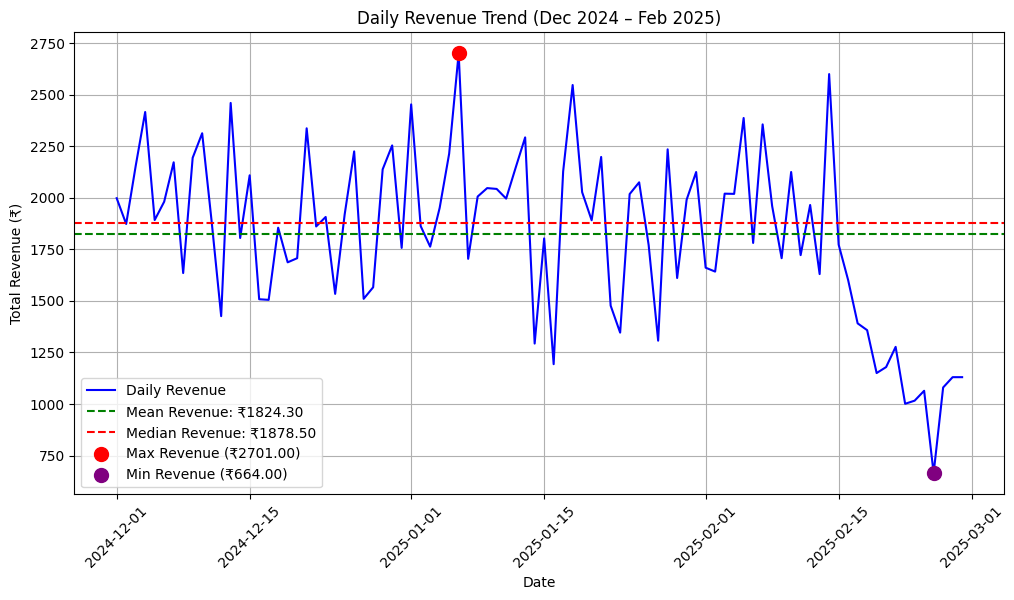

In [3]:
# Converting 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Compute key statistics
mean_revenue = df["Total Revenue"].mean()
max_revenue = df["Total Revenue"].max()
min_revenue = df["Total Revenue"].min()
median_revenue = df["Total Revenue"].median()

# Identifying dates corresponding to max and min revenue
max_date = df[df["Total Revenue"] == max_revenue]["Date"].values[0]
min_date = df[df["Total Revenue"] == min_revenue]["Date"].values[0]

# Plotting revenue trend
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Total Revenue'], linestyle='-', label="Daily Revenue", color="blue")

# Adding horizontal lines for mean and max revenue
plt.axhline(mean_revenue, color='green', linestyle="--", label=f"Mean Revenue: ₹{mean_revenue:.2f}")
plt.axhline(median_revenue, color='red', linestyle="--", label=f"Median Revenue: ₹{median_revenue:.2f}")

# Adding markers for max and min revenue points
plt.scatter(max_date, max_revenue, color="red", s=100, label=f"Max Revenue (₹{max_revenue:.2f})", zorder=3)
plt.scatter(min_date, min_revenue, color="purple", s=100, label=f"Min Revenue (₹{min_revenue:.2f})", zorder=3)

# Adding labels, title & performing formatting
plt.xlabel("Date")
plt.ylabel("Total Revenue (₹)")
plt.title("Daily Revenue Trend (Dec 2024 – Feb 2025)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Showing the final plot
plt.show()

2.1. Plotting the product-wise revenue contribution

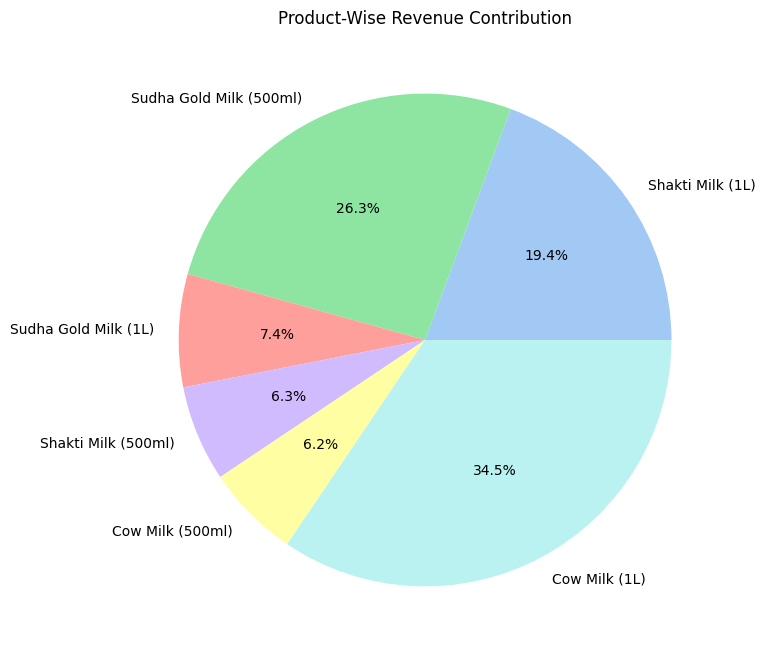

In [4]:
# Summing up total quantities sold per product
product_revenue = {
    "Shakti Milk (1L)": df["S M 1_Revenue"].sum(),
    "Sudha Gold Milk (500ml)": df["Gold 500_Revenue"].sum(),
    "Sudha Gold Milk (1L)": df["Gold 1_Revenue"].sum(),
    "Shakti Milk (500ml)": df["SM 500_Revenue"].sum(),
    "Cow Milk (500ml)": df["COW 500_Revenue"].sum(),
    "Cow Milk (1L)": df["COW 1_Revenue"].sum()
}


# Converting dictionary to DataFrame
revenue_df = pd.DataFrame(list(product_revenue.items()), columns=["Product", "Total Revenue"])

# Plotting Pie Chart
plt.figure(figsize=(8,8))
plt.pie(revenue_df["Total Revenue"], labels=revenue_df["Product"], autopct="%1.1f%%", colors=sns.color_palette("pastel6"))
plt.title("Product-Wise Revenue Contribution")
plt.show()

2.2. Comparing the revenue generated by 1L variants and 500ml Variants

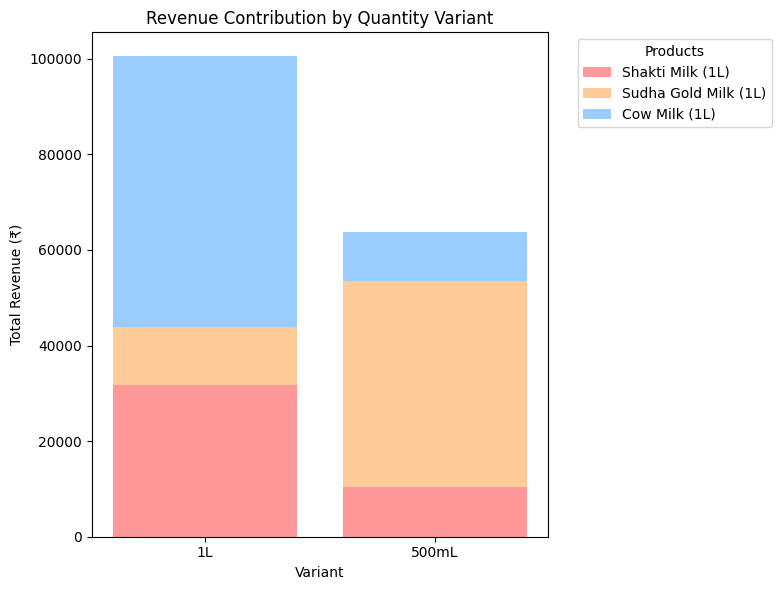

In [5]:
# Defining individual product revenues
product_revenue = {
    "Shakti Milk (1L)": df["S M 1_Revenue"].sum(),
    "Sudha Gold Milk (1L)": df["Gold 1_Revenue"].sum(),
    "Cow Milk (1L)": df["COW 1_Revenue"].sum(),
    "Shakti Milk (500ml)": df["SM 500_Revenue"].sum(),
    "Sudha Gold Milk (500ml)": df["Gold 500_Revenue"].sum(),
    "Cow Milk (500ml)": df["COW 500_Revenue"].sum()
}

# Categorizing into 1L and 500mL groups
categories = {
    "1L": {
        "Shakti Milk (1L)": product_revenue["Shakti Milk (1L)"],
        "Sudha Gold Milk (1L)": product_revenue["Sudha Gold Milk (1L)"],
        "Cow Milk (1L)": product_revenue["Cow Milk (1L)"]
    },
    "500mL": {
        "Shakti Milk (500ml)": product_revenue["Shakti Milk (500ml)"],
        "Sudha Gold Milk (500ml)": product_revenue["Sudha Gold Milk (500ml)"],
        "Cow Milk (500ml)": product_revenue["Cow Milk (500ml)"]
    }
}

# Preparing data for stacked bar
labels = ["1L", "500mL"]
product_names = []
bar_data = []

for cat in labels:
    revenues = list(categories[cat].values())
    product_names.append(list(categories[cat].keys()))
    bar_data.append(revenues)

# Transposing bar_data to get stacks
stack_data = list(zip(*bar_data))

# Plotting the graph
colors = ["#FF9999", "#FFCC99", "#99CCFF", "#FFB6C1", "#87CEFA", "#FFD700"]
plt.figure(figsize=(8,6))

bottoms = [0, 0]
for i, values in enumerate(stack_data):
    plt.bar(labels, values, bottom=bottoms, label=product_names[0][i], color=colors[i])
    bottoms = [sum(x) for x in zip(bottoms, values)]

#Adding title and labels
plt.title("Revenue Contribution by Quantity Variant")
plt.ylabel("Total Revenue (₹)")
plt.xlabel("Variant")
plt.legend(title="Products", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

3. Analysing the sales conversion rates of individual products

<ipython-input-6-3ab950a0813c>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Sales Conversion Rate (%)", y="Product", data=conversion_df, palette="pastel")


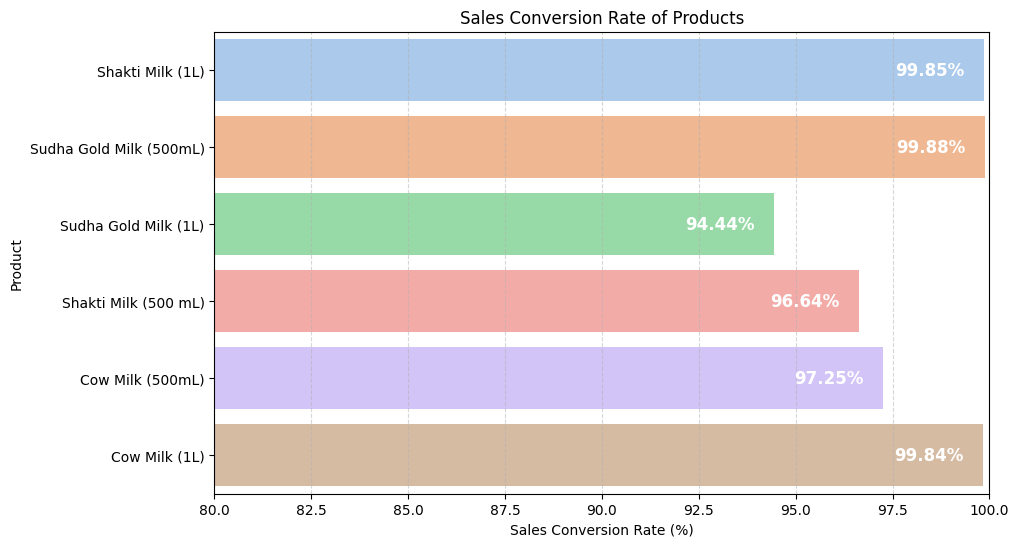

In [6]:
# Computing sales conversion rates (sold quantity / purchased quantity)
conversion_rates = {
    "Shakti Milk (1L)": (df["S M 1_Quantity"].sum() / 663) * 100,
    "Sudha Gold Milk (500mL)": (df["Gold 500_Quantity"].sum() / 1603) * 100,
    "Sudha Gold Milk (1L)": (df["Gold 1_Quantity"].sum() / 234) * 100,
    "Shakti Milk (500 mL)": (df["SM 500_Quantity"].sum() / 446) * 100,
    "Cow Milk (500mL)": (df["COW 500_Quantity"].sum() / 473) * 100,
    "Cow Milk (1L)": (df["COW 1_Quantity"].sum() / 1259) * 100
}

# Converting to DataFrame
conversion_df = pd.DataFrame(list(conversion_rates.items()), columns=["Product", "Sales Conversion Rate (%)"])

# Plotting bar chart for conversion rate
plt.figure(figsize=(10,6))
ax = sns.barplot(x="Sales Conversion Rate (%)", y="Product", data=conversion_df, palette="pastel")

# Adding percentage labels inside bars
for index, value in enumerate(conversion_df["Sales Conversion Rate (%)"]):
    ax.text(value - 0.5, index, f"{value:.2f}%", va="center", ha="right", fontsize=12, color="white", fontweight="bold")

# Performing formatting
plt.xlabel("Sales Conversion Rate (%)")
plt.ylabel("Product")
plt.title("Sales Conversion Rate of Products")
plt.xlim(80, 100)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Showing the final plot
plt.show()


Calculating the profit margins of individual products

<ipython-input-7-785ea6ad107d>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Net Profit/Loss (₹)", y="Product", data=profit_df, palette=["blue" if x > 0 else "yellow" for x in profit_df["Net Profit/Loss (₹)"]])


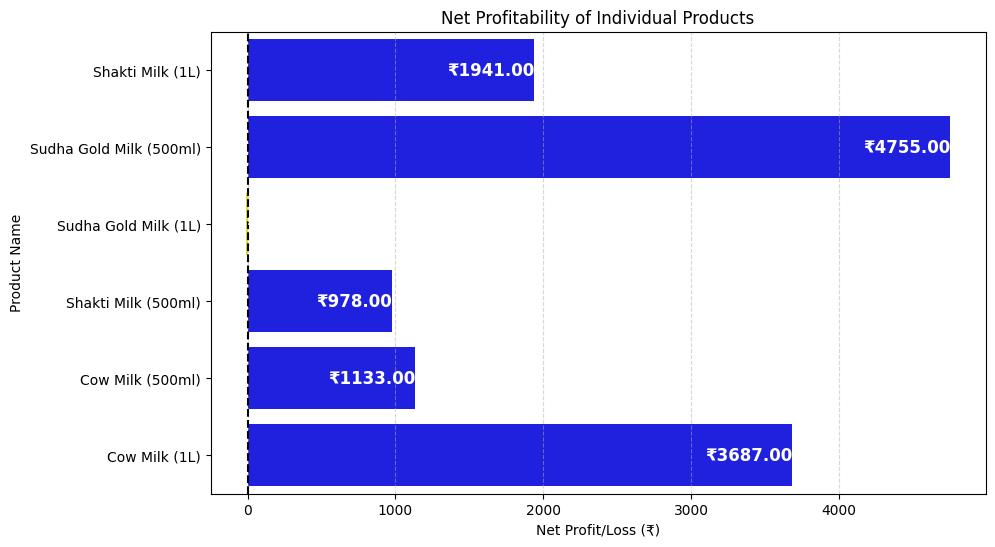

In [7]:
# Defining purchase cost per unit
cost_prices = {
    "S M 1L": 45, "Gold 500ml": 24, "Gold 1L": 52, "SM 500ml": 21, "Cow 500ml": 19, "Cow 1L": 42
}

# Computing total profit/loss per product
profit_loss = {
    "Shakti Milk (1L)": df["S M 1_Revenue"].sum() - (663 * cost_prices["S M 1L"]),
    "Sudha Gold Milk (500ml)": df["Gold 500_Revenue"].sum() - (1603 * cost_prices["Gold 500ml"]),
    "Sudha Gold Milk (1L)": df["Gold 1_Revenue"].sum() - (234 * cost_prices["Gold 1L"]),
    "Shakti Milk (500ml)": df["SM 500_Revenue"].sum() - (446 * cost_prices["SM 500ml"]),
    "Cow Milk (500ml)": df["COW 500_Revenue"].sum() - (473 * cost_prices["Cow 500ml"]),
    "Cow Milk (1L)": df["COW 1_Revenue"].sum() - (1259 * cost_prices["Cow 1L"])
}

# Converting to DataFrame
profit_df = pd.DataFrame(list(profit_loss.items()), columns=["Product", "Net Profit/Loss (₹)"])

# Plotting bar chart
plt.figure(figsize=(10,6))
ax = sns.barplot(x="Net Profit/Loss (₹)", y="Product", data=profit_df, palette=["blue" if x > 0 else "yellow" for x in profit_df["Net Profit/Loss (₹)"]])

# Adding labels inside bars
for index, value in enumerate(profit_df["Net Profit/Loss (₹)"]):
    ax.text(value, index, f"₹{value:.2f}", va="center", ha="right" if value > 0 else "left", fontsize=12, color="white", fontweight="bold")

# Performing formatting
plt.xlabel("Net Profit/Loss (₹)")
plt.ylabel("Product Name")
plt.title("Net Profitability of Individual Products")
plt.axvline(0, color="black", linestyle="--")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Showing the final plot
plt.show()

Assessing the optimal purchase quantity of individual products

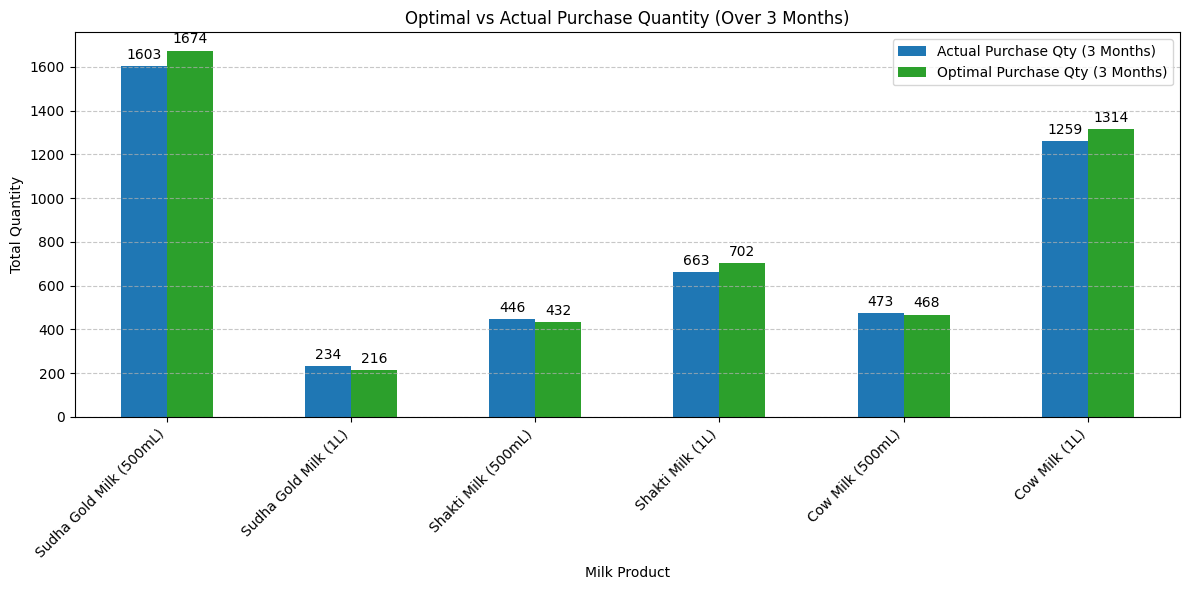

In [10]:
# Actual purchase quantities during the 3-month period
actual_purchases = {
    "Gold 500_Quantity": 1603,
    "Gold 1_Quantity": 234,
    "SM 500_Quantity": 446,
    "S M 1_Quantity": 663,
    "COW 500_Quantity": 473,
    "COW 1_Quantity": 1259
}

# Restocking frequency and safety margin
restocking_period = 5
safety_margin = 1.05

# Mapping product names to column names
product_columns = {
    "Sudha Gold Milk (500mL)": "Gold 500_Quantity",
    "Sudha Gold Milk (1L)": "Gold 1_Quantity",
    "Shakti Milk (500mL)": "SM 500_Quantity",
    "Shakti Milk (1L)": "S M 1_Quantity",
    "Cow Milk (500mL)": "COW 500_Quantity",
    "Cow Milk (1L)": "COW 1_Quantity"
}

# Calculating the optimal purchase quantity per 5-day restocking
optimal_purchase = {}
total_days = df.shape[0]

for product, column in product_columns.items():
    total_sold = df[column].sum()
    avg_daily_sales = total_sold / total_days
    actual_purchased = actual_purchases[column]
    conversion_rate = total_sold / actual_purchased if actual_purchased > 0 else 0
    adjustment_factor = min(conversion_rate, 1.0)
    recommended_qty = avg_daily_sales * restocking_period * adjustment_factor * safety_margin
    optimal_purchase[product] = round(recommended_qty)

# Converting dictionaries to DataFrames
optimal_df = pd.DataFrame.from_dict(optimal_purchase, orient='index', columns=['Recommended Purchase Qty (5 Days)'])
optimal_df.index.name = 'Product'
optimal_df['Optimal Purchase Qty (3 Months)'] = optimal_df['Recommended Purchase Qty (5 Days)'] * 18

# Preparing actual purchase DataFrame
column_to_product = {v: k for k, v in product_columns.items()}
actual_df = pd.DataFrame.from_dict(actual_purchases, orient='index', columns=['Actual Purchase Qty (3 Months)'])
actual_df.index = actual_df.index.map(column_to_product)

# Combining for comparison
comparison_df = actual_df.join(optimal_df['Optimal Purchase Qty (3 Months)'])

# Plotting the final graph
ax = comparison_df.plot(kind='bar', figsize=(12, 6), color=["#1f77b4", "#2ca02c"])
plt.title("Optimal vs Actual Purchase Quantity (Over 3 Months)")
plt.ylabel("Total Quantity")
plt.xlabel("Milk Product")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Adding labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3)

plt.show()